# Milestone 3 — Phase 2: Node Classification

**CS343 Graph Data Science — Spring 2026**  
**Team:** Muhammad Ammar Maqdoom, Ali Anwar  
**Dataset:** Football Transfers 2017/2018

## ML Problem
Classify each `Club` node as `HighBuyer` (1) or `LowBuyer` (0).

## Features used
- Transactional: `buyCount`, `sellCount`, `avgBuyFee`, `avgSellFee`, `crossBorderBuyRatio`
- Graph-derived: `community` (Louvain), `pagerank`, `embedding` (FastRP, 64-dim)

## Models
- Random Forest
- Random Forest (class-balanced)
- Logistic Regression
- XGBoost

## Prerequisites
- Run `football_transfers_M2_final_5.cypher` (data loading)
- Run `M3_phase1_feature_engineering.cypher` (feature engineering)

## 1. Imports and Neo4j Connection

In [2]:
from neo4j import GraphDatabase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
)

URI = "neo4j://127.0.0.1:7687"
USER = "neo4j"
PASSWORD = "neo4j12345"

driver = GraphDatabase.driver(URI, auth=(USER, PASSWORD))

def run_query(query, params=None):
    with driver.session() as session:
        result = session.run(query, params or {})
        return result.to_df()

print("Connected to Neo4j at", URI)

Connected to Neo4j at neo4j://127.0.0.1:7687


## 2. Fetch Features from Neo4j

We pull all per-club features and the supervised label `buyerClass`.

In [3]:
query = """
MATCH (c:Club)
WHERE c.embedding IS NOT NULL
  AND c.community IS NOT NULL
  AND c.pagerank  IS NOT NULL
  AND c.buyerClass IS NOT NULL
RETURN
  elementId(c)            AS id,
  c.name                  AS name,
  c.buyCount              AS buyCount,
  c.sellCount             AS sellCount,
  c.avgBuyFee             AS avgBuyFee,
  c.avgSellFee            AS avgSellFee,
  c.crossBorderBuyRatio   AS crossBorderBuyRatio,
  c.community             AS community,
  c.pagerank              AS pagerank,
  c.embedding             AS embedding,
  c.buyerClass            AS buyerClass
"""

df = run_query(query)
print("Rows:", len(df))
df.head()

Rows: 7552


,id,name,buyCount,sellCount,avgBuyFee,avgSellFee,crossBorderBuyRatio,community,pagerank,embedding,buyerClass
0,4:0696f726-4818-49ec-b271-46c90e3cf920:24598,Monaco,8.0,12.0,6.525000,13.387500,0.875000,2929,1.885704,"[0.29204604029655457, 0.04197944700717926, -0....",1
1,4:0696f726-4818-49ec-b271-46c90e3cf920:24599,AS Roma,12.0,27.0,6.823636,3.617308,0.583333,1020,3.838997,"[0.39190319180488586, -0.2454390972852707, 0.1...",1
2,4:0696f726-4818-49ec-b271-46c90e3cf920:24600,Olympique Lyon,7.0,14.0,4.950000,7.634286,0.714286,2929,2.280135,"[0.04167858883738518, -0.1361493170261383, 0.1...",1
3,4:0696f726-4818-49ec-b271-46c90e3cf920:24601,Benfica,11.0,13.0,0.347727,7.843846,0.181818,1500,2.331364,"[0.09421956539154053, -0.26478245854377747, -0...",1
4,4:0696f726-4818-49ec-b271-46c90e3cf920:24602,FC Porto,5.0,13.0,0.180000,4.818462,0.000000,410,1.822285,"[0.034344740211963654, -0.17482635378837585, -...",1


In [4]:
embedding_df = pd.DataFrame(
    df["embedding"].tolist(),
    columns=[f"emb_{i}" for i in range(len(df["embedding"].iloc[0]))],
)

feature_df = pd.concat(
    [
        df[[
            "id",
            "name",
            "buyCount",
            "sellCount",
            "avgBuyFee",
            "avgSellFee",
            "crossBorderBuyRatio",
            "community",
            "pagerank",
            "buyerClass",
        ]],
        embedding_df,
    ],
    axis=1,
)

print("Feature matrix shape:", feature_df.shape)
feature_df.head()

Feature matrix shape: (7552, 74)


,id,name,buyCount,sellCount,avgBuyFee,avgSellFee,crossBorderBuyRatio,community,pagerank,buyerClass,...,emb_54,emb_55,emb_56,emb_57,emb_58,emb_59,emb_60,emb_61,emb_62,emb_63
0,4:0696f726-4818-49ec-b271-46c90e3cf920:24598,Monaco,8.0,12.0,6.525000,13.387500,0.875000,2929,1.885704,1,...,0.128531,-0.136875,0.077559,-0.126811,-0.305500,-0.449383,0.290352,-0.009947,-0.082919,-0.045244
1,4:0696f726-4818-49ec-b271-46c90e3cf920:24599,AS Roma,12.0,27.0,6.823636,3.617308,0.583333,1020,3.838997,1,...,0.081810,-0.101636,0.006552,-0.302062,-0.068435,-0.559886,-0.007602,0.134068,0.227752,-0.001276
2,4:0696f726-4818-49ec-b271-46c90e3cf920:24600,Olympique Lyon,7.0,14.0,4.950000,7.634286,0.714286,2929,2.280135,1,...,0.021882,-0.181331,0.092711,-0.084523,-0.148730,-0.440744,0.283957,-0.081176,-0.065383,-0.238263
3,4:0696f726-4818-49ec-b271-46c90e3cf920:24601,Benfica,11.0,13.0,0.347727,7.843846,0.181818,1500,2.331364,1,...,-0.156076,-0.009062,-0.326388,-0.452227,-0.254312,-0.510396,-0.182359,-0.044108,0.136985,-0.266823
4,4:0696f726-4818-49ec-b271-46c90e3cf920:24602,FC Porto,5.0,13.0,0.180000,4.818462,0.000000,410,1.822285,1,...,0.089316,-0.036898,0.025209,-0.173661,-0.302010,-0.101622,-0.018866,0.160417,0.175489,-0.174063


## 3. Class Balance and Basic Statistics

In [5]:
print("Class distribution:")
print(feature_df["buyerClass"].value_counts())

print("\nFeature summary:")
feature_df[[
    "buyCount",
    "sellCount",
    "avgBuyFee",
    "avgSellFee",
    "crossBorderBuyRatio",
    "community",
    "pagerank",
]].describe()

Class distribution:
buyerClass
0    5611
1    1941
Name: count, dtype: int64

Feature summary:


,buyCount,sellCount,avgBuyFee,avgSellFee,crossBorderBuyRatio,community,pagerank
count,7552.000000,7552.000000,7552.000000,7552.000000,7552.000000,7552.000000,7552.000000
mean,2.693326,2.690943,0.139737,0.104956,0.158125,2211.314354,0.961133
std,3.578466,3.512368,1.619578,1.457344,0.309689,2070.587100,0.708557
min,0.000000,0.000000,0.000000,0.000000,0.000000,279.000000,0.150000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,453.000000,0.409688
50%,1.000000,1.000000,0.000000,0.000000,0.000000,1042.000000,0.750374
75%,4.000000,4.000000,0.000000,0.000000,0.142857,4211.000000,1.265035
max,27.000000,40.000000,71.400000,94.500000,1.000000,7550.000000,5.444471


## 4. Train/Test Split

> **Note on data leakage.** The label `buyerClass` is defined in Phase 1 as `1` if `buyCount` is in the top quartile, else `0`. Because `buyerClass` is a deterministic function of `buyCount` (and `sellCount` is highly correlated with `buyCount`), feeding either column into the model would let it recover the label perfectly and report ~100% accuracy without learning anything from the graph. We therefore drop both `buyCount` and `sellCount` from the feature matrix `X`, forcing the classifiers to rely on the remaining transactional features (`avgBuyFee`, `avgSellFee`, `crossBorderBuyRatio`) and the graph-derived features (`community`, `pagerank`, and the 64-dim FastRP `embedding`).

In [6]:
leakage_cols = ["buyCount", "sellCount"]
drop_cols = ["id", "name", "buyerClass"] + leakage_cols
X = feature_df.drop(columns=drop_cols)
y = feature_df["buyerClass"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print("Dropped to prevent leakage:", leakage_cols)
print("Feature matrix shape:", X.shape)
print("Train size:", len(X_train), "Test size:", len(X_test))

Dropped to prevent leakage: ['buyCount', 'sellCount']
Feature matrix shape: (7552, 69)
Train size: 6041 Test size: 1511


## 5. Random Forest (baseline)

In [7]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest (baseline)")
print(classification_report(y_test, y_pred_rf, digits=4))
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))

Random Forest (baseline)
              precision    recall  f1-score   support

           0     0.9320    0.9403    0.9362      1123
           1     0.8228    0.8015    0.8120       388

    accuracy                         0.9047      1511
   macro avg     0.8774    0.8709    0.8741      1511
weighted avg     0.9040    0.9047    0.9043      1511

Accuracy: 0.9047


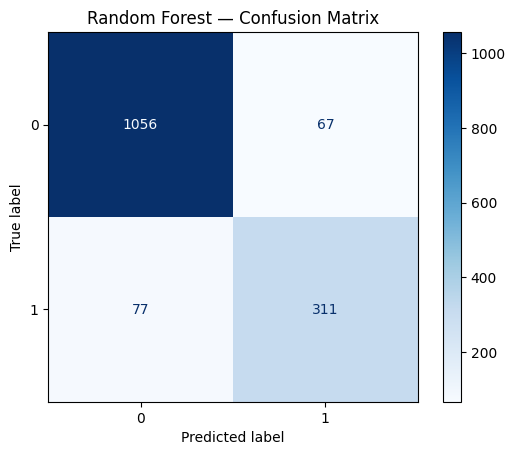

In [8]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap="Blues")
plt.title("Random Forest — Confusion Matrix")
plt.show()

## 6. Random Forest (class-balanced)

Using `class_weight="balanced"` to compensate for class imbalance.

In [9]:
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
)
rf_balanced.fit(X_train, y_train)

y_pred_rfb = rf_balanced.predict(X_test)
print("Random Forest (class-balanced)")
print(classification_report(y_test, y_pred_rfb, digits=4))

Random Forest (class-balanced)
              precision    recall  f1-score   support

           0     0.9264    0.9421    0.9342      1123
           1     0.8238    0.7835    0.8032       388

    accuracy                         0.9014      1511
   macro avg     0.8751    0.8628    0.8687      1511
weighted avg     0.9001    0.9014    0.9006      1511



## 7. Logistic Regression

Standardize features first since logistic regression is scale-sensitive.

In [10]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

log_reg = LogisticRegression(
    solver="lbfgs",
    max_iter=2000,
    class_weight="balanced",
    random_state=42,
)
log_reg.fit(X_train_sc, y_train)

y_pred_lr = log_reg.predict(X_test_sc)
print("Logistic Regression (class-balanced)")
print(classification_report(y_test, y_pred_lr, digits=4))

Logistic Regression (class-balanced)
              precision    recall  f1-score   support

           0     0.9546    0.8994    0.9262      1123
           1     0.7506    0.8763    0.8086       388

    accuracy                         0.8934      1511
   macro avg     0.8526    0.8878    0.8674      1511
weighted avg     0.9022    0.8934    0.8960      1511



## 8. XGBoost

In [11]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print("XGBoost")
print(classification_report(y_test, y_pred_xgb, digits=4))

XGBoost
              precision    recall  f1-score   support

           0     0.9379    0.9421    0.9400      1123
           1     0.8303    0.8196    0.8249       388

    accuracy                         0.9107      1511
   macro avg     0.8841    0.8809    0.8825      1511
weighted avg     0.9103    0.9107    0.9105      1511



## 9. Model Comparison

In [12]:
results = {
    "RandomForest":              accuracy_score(y_test, y_pred_rf),
    "RandomForest (balanced)":   accuracy_score(y_test, y_pred_rfb),
    "LogisticRegression":        accuracy_score(y_test, y_pred_lr),
    "XGBoost":                   accuracy_score(y_test, y_pred_xgb),
}

results_df = pd.DataFrame(
    sorted(results.items(), key=lambda x: -x[1]),
    columns=["Model", "Accuracy"],
)
results_df

,Model,Accuracy
0,XGBoost,0.910655
1,RandomForest,0.904699
2,RandomForest (balanced),0.901390
3,LogisticRegression,0.893448


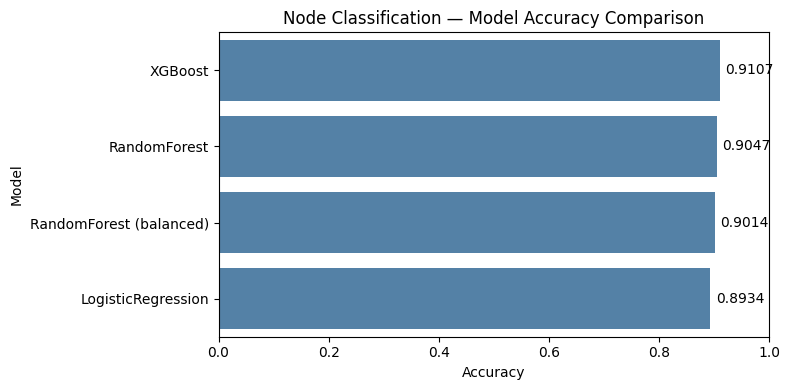

In [13]:
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="Accuracy", y="Model", color="steelblue")
plt.xlim(0, 1)
plt.title("Node Classification — Model Accuracy Comparison")
for i, v in enumerate(results_df["Accuracy"]):
    plt.text(v + 0.01, i, f"{v:.4f}", va="center")
plt.tight_layout()
plt.show()

## 10. Feature Importance (Random Forest)

In [14]:
importances = pd.DataFrame({
    "feature":   X.columns,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)

print("Top 15 features:")
importances.head(15)

Top 15 features:


,feature,importance
4,pagerank,0.355065
2,crossBorderBuyRatio,0.087741
1,avgSellFee,0.025985
0,avgBuyFee,0.019381
42,emb_37,0.013334
41,emb_36,0.011492
3,community,0.011219
64,emb_59,0.011127
56,emb_51,0.011014
65,emb_60,0.010509


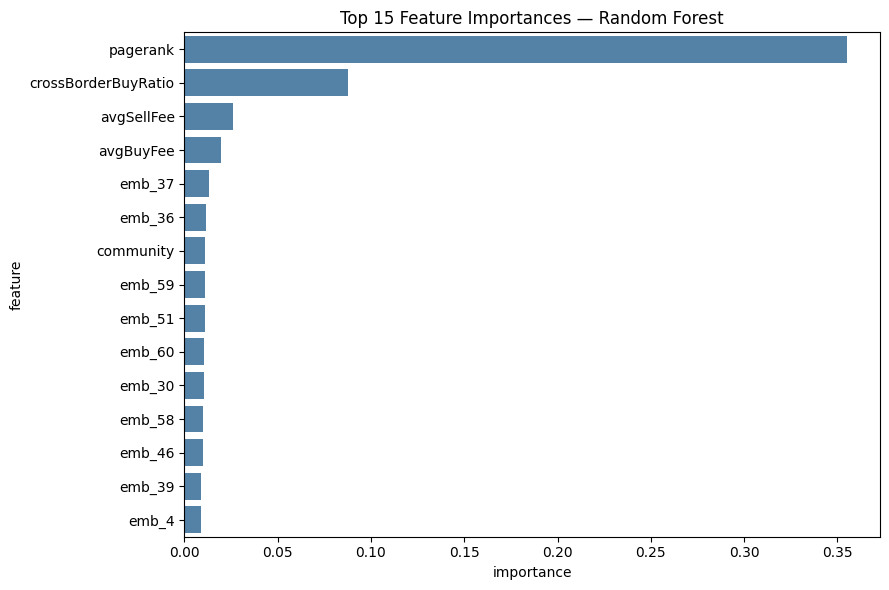

In [15]:
top_n = 15
plt.figure(figsize=(9, 6))
sns.barplot(
    data=importances.head(top_n),
    x="importance",
    y="feature",
    color="steelblue",
)
plt.title(f"Top {top_n} Feature Importances — Random Forest")
plt.tight_layout()
plt.show()

## 11. Sample Predictions (Test Set)

In [16]:
test_meta = feature_df.loc[X_test.index, ["name"]].copy()
test_meta["actual"]    = y_test.values
test_meta["predicted"] = y_pred_rf
test_meta["correct"]   = test_meta["actual"] == test_meta["predicted"]
test_meta.head(20)

,name,actual,predicted,correct
2740,Sliema Wander.,0,0,True
7519,Pavarolo,0,0,True
5168,Egersunds IK,0,1,False
970,Barakaldo CF,1,1,True
4788,Chalatenango,0,0,True
6018,Herediano,0,0,True
3092,Loko Vltavin,0,0,True
2377,CR Al Hoceima,1,1,True
1712,CS Hammam-Lif,1,1,True
5315,Savio Rocchetta,0,0,True


In [17]:
driver.close()
print("Phase 2 complete. Now run Phase 3 notebook for link prediction.")

Phase 2 complete. Now run Phase 3 notebook for link prediction.
